In [1]:
# Requirement Library for Machine Learning Model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset + Basic Information
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Let's See First 5 Row of Dataset")
print(df.head())

print("Dataset shape (rows, columns):", df.shape)

print("\nDataset info:")
print(df.info())

print("\nSummary statistics of numerical columns:")
print(df.describe())

Let's See First 5 Row of Dataset
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

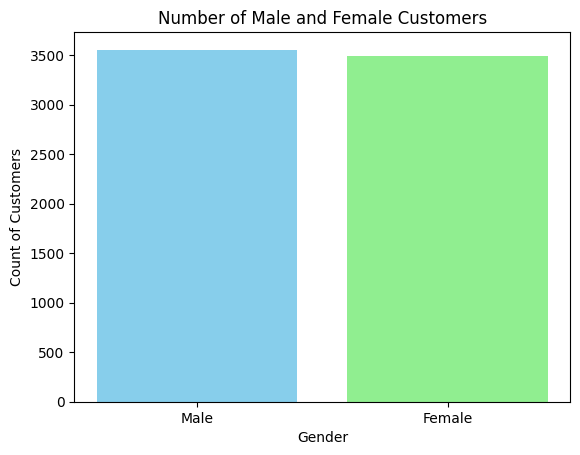

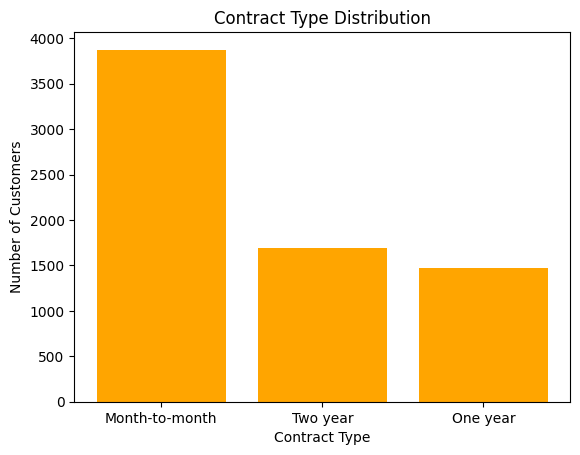

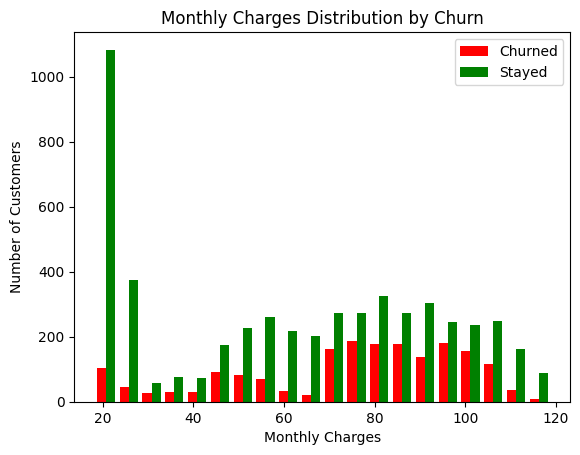

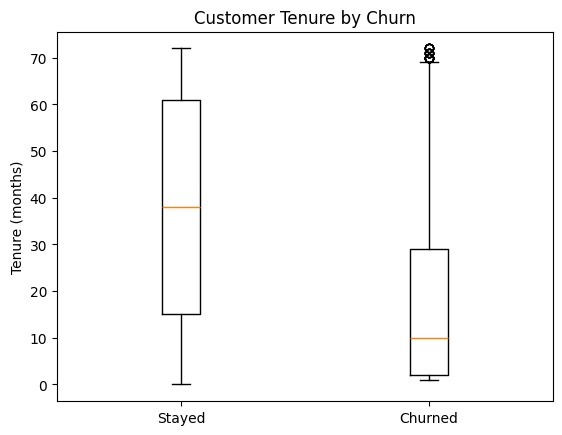

In [3]:
# EDA Graphs
# Gender Distribution
gender_counts = df['gender'].value_counts()

plt.bar(gender_counts.index, gender_counts.values, color=['skyblue','lightgreen'])
plt.title('Number of Male and Female Customers')
plt.xlabel('Gender')
plt.ylabel('Count of Customers')
plt.show()


# Contract Type Distribution
contract_counts = df['Contract'].value_counts()

plt.bar(contract_counts.index, contract_counts.values, color='orange')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()


# Monthly Charges Distribution
churned = df[df['Churn'] == 'Yes']['MonthlyCharges']
stayed = df[df['Churn'] == 'No']['MonthlyCharges']

plt.hist([churned, stayed], bins=20, color=['red','green'], label=['Churned','Stayed'])
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()


# Tenure vs Churn
plt.boxplot([df[df['Churn']=='No']['tenure'], df[df['Churn']=='Yes']['tenure']],
            tick_labels=['Stayed','Churned'])
plt.title('Customer Tenure by Churn')
plt.ylabel('Tenure (months)')
plt.show()

In [4]:
# 1. Remove unnecessary ID columns 
clean_data = df.drop(['customerID'], axis=1)

# 2. Convert Yes/No columns to numerical values
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in yes_no_columns:
    clean_data[col] = clean_data[col].map({'Yes': 1, 'No': 0})

# 3. convert TotalCharges into numeric 
clean_data['TotalCharges'] = pd.to_numeric(clean_data['TotalCharges'], errors='coerce')

# 🔥 Better missing value handling
clean_data['TotalCharges'] = clean_data['TotalCharges'].fillna(clean_data['TotalCharges'].median())

# 4. One-hot encoding
final_data = pd.get_dummies(clean_data)


print("✔ Data Cleaning Done")

✔ Data Cleaning Done


In [5]:
# Save only input columns (without Churn)
import pickle

input_columns = final_data.drop('Churn', axis=1).columns
pickle.dump(input_columns, open("columns.pkl", "wb"))

print("columns.pkl saved successfully")

columns.pkl saved successfully


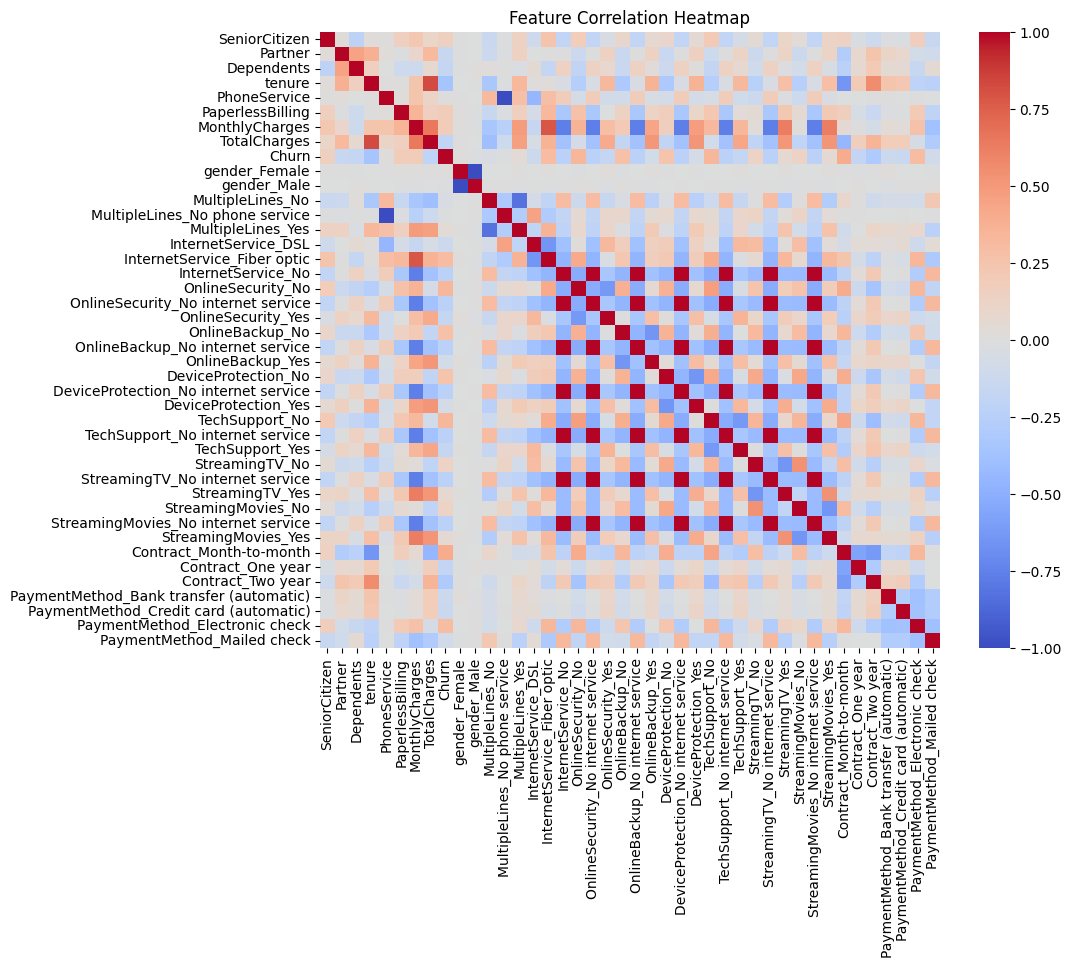

In [6]:
# 🔥 Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(final_data.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# 🎯 Creating Features and Target

# Target column (what we want to predict)
target = final_data['Churn']

# Features (all columns except target)
inputs = final_data.drop('Churn', axis=1)

print("✔ Features and target created")
print("Input shape:", inputs.shape)
print("Target shape:", target.shape)

✔ Features and target created
Input shape: (7043, 41)
Target shape: (7043,)


In [8]:
# 🔀 Splitting Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    inputs, 
    target, 
    test_size=0.20,   # 20% data testing ke liye
    random_state=42   # same result ke liye fix
)

print("✔ Data split successfully")
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

✔ Data split successfully
Training data size: (5634, 41)
Testing data size: (1409, 41)


In [9]:
# 📏 Feature Scaling

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("✔ Feature scaling completed")
print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

✔ Feature scaling completed
Scaled Training Data Shape: (5634, 41)
Scaled Testing Data Shape: (1409, 41)


In [10]:
# 🤖 Model Training - Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=5000)

# Train model on scaled training data
model.fit(X_train_scaled, y_train)

print("✔ Logistic Regression model trained successfully")

✔ Logistic Regression model trained successfully


In [11]:
# 🔍 Feature Importance (Why customers churn)

import pandas as pd

# Get importance from Logistic Regression
importance = model.coef_[0]

# Get feature names
features = X_train.columns

# Create dataframe
imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

# Sort by importance
imp_df = imp_df.sort_values(by="Importance", ascending=False)

print("Top 10 Important Features:\n")
print(imp_df.head(10))

Top 10 Important Features:

                           Feature  Importance
7                     TotalCharges    0.636203
14     InternetService_Fiber optic    0.351414
34         Contract_Month-to-month    0.310978
5                 PaperlessBilling    0.163502
33             StreamingMovies_Yes    0.160267
30                 StreamingTV_Yes    0.135473
16               OnlineSecurity_No    0.118932
39  PaymentMethod_Electronic check    0.118925
25                  TechSupport_No    0.100379
12               MultipleLines_Yes    0.087304


In [12]:
# 🌲 Model Comparison - Random Forest

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf = RandomForestClassifier(random_state=42)

# Train model on original (non-scaled) data
rf.fit(X_train, y_train)

# Accuracy compare
logistic_acc = model.score(X_test_scaled, y_test)
rf_acc = rf.score(X_test, y_test)

print("Logistic Regression Accuracy:", round(logistic_acc*100,2), "%")
print("Random Forest Accuracy:", round(rf_acc*100,2), "%")

Logistic Regression Accuracy: 81.97 %
Random Forest Accuracy: 79.13 %


In [13]:
# 🔮 Prediction on Test Data

y_pred = model.predict(X_test_scaled)

print("✔ Prediction completed")
print("Sample Predictions:", y_pred[:10])

✔ Prediction completed
Sample Predictions: [1 0 0 1 0 0 0 0 0 0]


Model Accuracy: 81.97 %
Recall Score: 0.5951742627345844


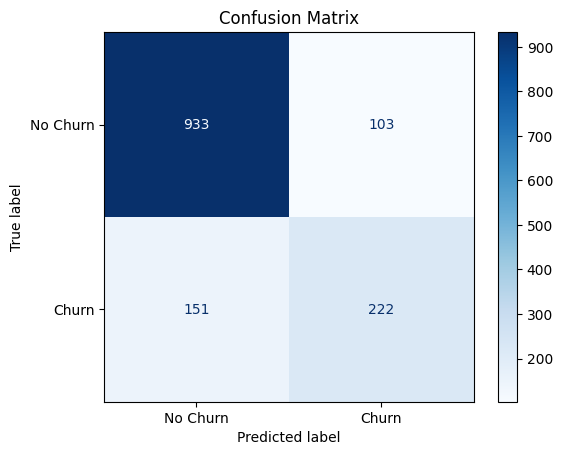


Classification Report:
               precision    recall  f1-score   support

    No Churn       0.86      0.90      0.88      1036
       Churn       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [14]:
# 📊 Model Evaluation

from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy*100,2), "%")

# Recall (important for churn)
recall = recall_score(y_test, y_pred)
print("Recall Score:", recall)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_test, y_pred, target_names=['No Churn','Churn'])
print("\nClassification Report:\n", report)

In [15]:
# 🚦 Risk Segmentation

# Get probability of churn
probs = model.predict_proba(X_test_scaled)[:, 1]

# Function to assign risk level
def risk_level(p):
    if p > 0.7:
        return "High Risk"
    elif p > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

# Apply function
risk = [risk_level(p) for p in probs]

print("✔ Risk segmentation completed")
print("Sample Risk Levels:", risk[:10])

✔ Risk segmentation completed
Sample Risk Levels: ['Medium Risk', 'Low Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk']


In [16]:
# 💡 Business Recommendation System

print("📢 Business Recommendations for Sample Customers:\n")

for i, p in enumerate(probs[:10]):
    if p > 0.7:
        print(f"Customer {i}: High Risk → Offer discount / retention call")
    elif p > 0.4:
        print(f"Customer {i}: Medium Risk → Send promotional offers")
    else:
        print(f"Customer {i}: Low Risk → No action needed")

📢 Business Recommendations for Sample Customers:

Customer 0: Medium Risk → Send promotional offers
Customer 1: Low Risk → No action needed
Customer 2: Low Risk → No action needed
Customer 3: Medium Risk → Send promotional offers
Customer 4: Low Risk → No action needed
Customer 5: Low Risk → No action needed
Customer 6: Low Risk → No action needed
Customer 7: Low Risk → No action needed
Customer 8: Low Risk → No action needed
Customer 9: Low Risk → No action needed


In [17]:
# 📊 Summary Statistics

# Total customers in test dataset
total_customers = len(y_test)

# Actual churn and stayed customers
actual_churn = sum(y_test)
actual_stayed = total_customers - actual_churn

# Predicted churn and stayed customers
predicted_churn = sum(y_pred)
predicted_stayed = total_customers - predicted_churn

# Accuracy
accuracy = model.score(X_test_scaled, y_test)

print("📊 Summary of Model Performance:\n")

print(f"Total customers in Test Data: {total_customers}")
print(f"Actual Churn Customers: {actual_churn}")
print(f"Actual Stayed Customers: {actual_stayed}")

print(f"\nPredicted Churn Customers: {predicted_churn}")
print(f"Predicted Stayed Customers: {predicted_stayed}")

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

📊 Summary of Model Performance:

Total customers in Test Data: 1409
Actual Churn Customers: 373
Actual Stayed Customers: 1036

Predicted Churn Customers: 325
Predicted Stayed Customers: 1084

Model Accuracy: 81.97%


In [18]:
# 📁 Create Final Data with Risk Level

# Example: define get_risk function
def get_risk(prob):
    """
    Assign risk based on churn probability
    prob: churn probability (0 to 1)
    returns: 'Low', 'Medium', or 'High'
    """
    if prob >= 0.7:
        return "High"
    elif prob >= 0.4:
        return "Medium"
    else:
        return "Low"

# If X_test doesn't have 'customerID', create a temporary ID column
if "customerID" not in X_test.columns:
    X_test = X_test.copy()
    X_test["customerID"] = range(1, len(X_test) + 1)

# Predicted values and risk
corrected_predicted = y_pred  # 1 = churn, 0 = stayed
corrected_risk = [get_risk(p) for p in probs]

# Combine everything into one dataframe
final_results = pd.DataFrame({
    "customerID": X_test["customerID"].values,
    "Actual_Churn": y_test.values,          # 0 = stayed, 1 = churn
    "Predicted_Churn": corrected_predicted, # 0 or 1
    "Churn_Probability": probs,
    "Risk_Level": corrected_risk
})

# Separate churn and non-churn customers (optional)
churn_customers = final_results[final_results["Predicted_Churn"] == 1]
non_churn_customers = final_results[final_results["Predicted_Churn"] == 0]

# Save CSV files
final_results.to_csv("Final_Results.csv", index=False)
churn_customers.to_csv("Churn_Customers_With_Risk.csv", index=False)
non_churn_customers.to_csv("NonChurn_Customers_With_Risk.csv", index=False)

print("✅ Files created successfully!")
print("1. Final_Results.csv (for Streamlit)")
print("2. Churn_Customers_With_Risk.csv (optional)")
print("3. NonChurn_Customers_With_Risk.csv (optional)")

✅ Files created successfully!
1. Final_Results.csv (for Streamlit)
2. Churn_Customers_With_Risk.csv (optional)
3. NonChurn_Customers_With_Risk.csv (optional)


In [19]:
# Save column names
import pickle

pickle.dump(final_data.columns, open("columns.pkl", "wb"))